### 인공지능 > 머신러닝 > 딥러닝
머신러닝 : 기계학습  
   지도학습  : 학습시 정답을 제공  
              회귀분석,분류   
   비지도학습 : 학습시 정답 제공안함 
              군집
머신러닝 프로세스  
   데이터 정리 : 전처리. 학습하기 좋은 데이터로 가공
   데이터 분리 : 훈련데이터, 검증데이터, 테스트 데이터 분리  
   알고리즘준비 : 알고리즘 별 특징을 이해하여 선택
   모형 학습   : 훈련 데이터를 이용하여 학습
   모형 평가   : 예측 결과로 모형 평가. 
   모형 활용   : 모형 결정             

In [ ]:
!pip3 install scikit-learn

In [3]:
# 단순 회귀 분석 : 독립변수가 1개
# 공부시간 : 독립변수
# 시험점수 : 종속변수. 
x = [[10],[5],[9],[7]] #공부시간  
y = [100,50,90,77]     #시험점수
from sklearn.linear_model import LinearRegression #선형회귀분석 모듈듀 #pip3 install scikit-learn
model = LinearRegression()
model.fit(x,y) #모델학습
#8시간 학습시 예측된 점수
result = model.predict([[8]])
print(result)



[81.66101695]


In [ ]:
#다중 회귀분석 : 독립변수가 여러개
# 공부시간,학년 : 독립변수
# 시험점수 : 종속변수
x = [[10,3],[5,2],[9,3],[7,3],[8,2],[3,1]]
y = [[100],[50],[90],[77],[85],[75]]
model = LinearRegression() #알고리즘 선택
model = model.fit(x,y)   #학습하기
result = model.predict([[7,2]])  #예측하기
print(result)


[[83.24226804]]


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv("auto-mpg.csv",header=None)
df.columns = ['mpg','cylinders','displacement','horsepower','weight',
              'acceleration','model year','origin','name'] 
df.head()


,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino


In [ ]:
df.horsepower.unique()

In [ ]:
#1. horsepower 컬럼의 ?값을 결측값(np.nan)으로 변경하기
df['horsepower'] = df['horsepower'].replace('?',np.nan)
df.info()

In [ ]:
#dropna : 결측값을 가진 행 데이터 삭제
ndf = df.dropna(subset=['horsepower'],axis=0)
ndf.info()

In [ ]:
#horsepower 컬럼의 자료형을 float형으로 변경하기
ndf['horsepower'] = ndf['horsepower'].astype(float)
ndf.info()

In [13]:
X = ndf[['cylinders','horsepower','weight']] #독립변수
Y = ndf['mpg'] #종속변수

In [ ]:
#데이터 분리하기 : 훈련,테스트 분리
from sklearn.model_selection import train_test_split
'''
train_test_split (독립변수,종속변수,테스트데이터의비율,seed값) 
'''
X_train,X_test,y_train,y_test = train_test_split(X,Y,test_size=0.3,random_state=10)
print("train data:",X_train.shape,y_train.shape)
print('test data:',X_test.shape,y_test.shape)

In [ ]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression() #모델 선택
lr.fit(X_train, y_train)

In [ ]:
y_hat = lr.predict(X_test)
print(y_hat[:10]) #예측데이터
print(y_test[:10]) #실제 정답데이터

[26.30243119 27.67960352 20.35480988 32.5663334  15.05079818 18.65250234
 16.5189694   8.21482855 30.00898418 28.56105525]
243    21.5
371    29.0
300    23.9
345    35.1
265    17.5
263    17.7
214    13.0
44     13.0
326    43.4
57     24.0
Name: mpg, dtype: float64


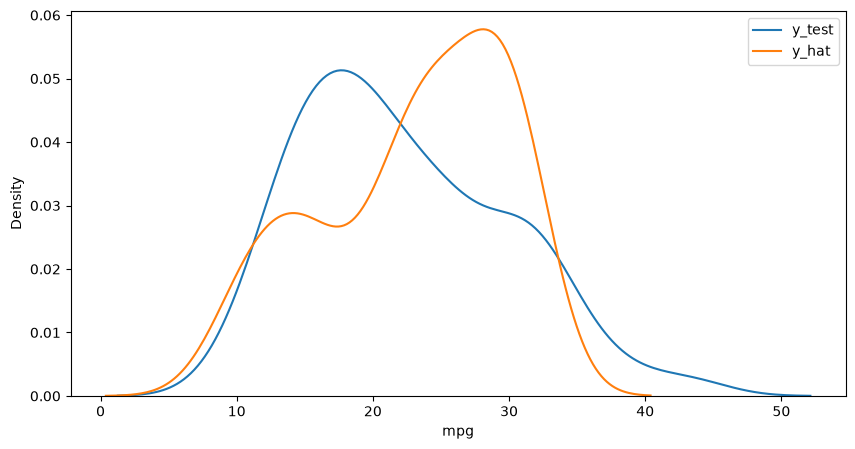

In [18]:
plt.figure(figsize=(10, 5))
ax1 = sns.kdeplot(y_test, label="y_test")
ax2 = sns.kdeplot(y_hat, label="y_hat", ax=ax1)
plt.legend()

Text(0, 0.5, 'mpg')

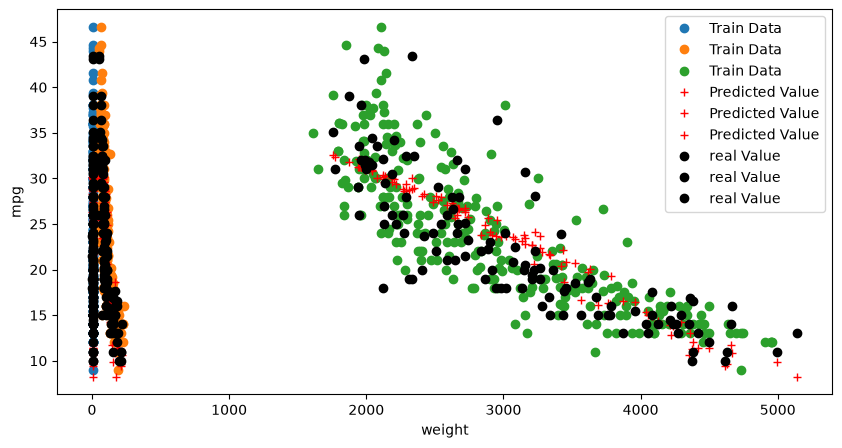

In [21]:
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(1, 1, 1)
ax.plot(X_train, y_train, 'o', label='Train Data')  # 데이터 분포
ax.plot(X_test, y_hat, 'r+', label='Predicted Value') # 모형이 학습한 회귀선
ax.plot(X_test, y_test, 'ko', label='real Value') # 모형이 학습한 회귀선
ax.legend(loc='best')
plt.xlabel('weight')
plt.ylabel('mpg')

In [ ]:
#평가 지표 출력하기
# 회귀분석의 평가지표 :  mse :평균제곱오차 => (실제데이터 - 예측데이터) 제곱합 / 건수 
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test,y_hat)
print("평균제곱오차(mse)",mse)
print("rmse:",np.sqrt(mse))

평균제곱오차(mse) 17.33008562898994
rmse: 4.1629419439850395


In [ ]:
#분류 : 질병진단, 스팸메일분류, 숫자인식
#    설명 변수 : 독립변수 개념
#    목표 변수 : 종속변수 개념. 범주형 데이터인 경우
#    알고리즘 : KNN(최근접 이웃 알고리즘)

# titanic 데이터로 생존여부를 판단하기
import seaborn as sns
import pandas as pd
df = sns.load_dataset('titanic')
df.info()

In [ ]:
#deck, embark_town 컬럼 제거하기
rdf = df.drop(['deck','embark_town'],axis=1)
rdf.info()

In [ ]:
#age 컬럼의 결측값을 가진 행을 삭제하기
rdf = rdf.dropna(subset=['age'],axis=0)
rdf.info()

In [30]:
#embarked 컬럼의 결측값을 최빈도값으로 치환하기
most_freq = rdf.embarked.value_counts().idxmax()
print(most_freq)
rdf['embarked'] = rdf['embarked'].fillna(most_freq)
rdf.embarked.value_counts()

S


embarked
S    556
C    130
Q     28
Name: count, dtype: int64

In [ ]:
#  분석에 필요한 컬럼 선택
ndf = rdf[['survived','pclass','sex','age','sibsp','parch','embarked']]
ndf.info()

In [ ]:
ndf.sex.value_counts()
ndf.embarked.value_counts()

In [ ]:
#원핫인코딩(DataFrame.get_dummies()) : 문자열 또는 범주형 데이터의 모형을 인식하도록 숫자형으로 변환함
#sex
onehot_sex = pd.get_dummies(ndf['sex'])
onehot_sex
#embarked
onehot_embarked = pd.get_dummies(ndf['embarked'],prefix='town')
onehot_embarked
#ndf에 컬럼을 추가하기
ndf = pd.concat([ndf,onehot_sex],axis=1)
ndf = pd.concat([ndf,onehot_embarked],axis=1)
ndf.info()

In [37]:
ndf.info()

<class 'pandas.DataFrame'>
Index: 714 entries, 0 to 890
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  714 non-null    int64  
 1   pclass    714 non-null    int64  
 2   sex       714 non-null    str    
 3   age       714 non-null    float64
 4   sibsp     714 non-null    int64  
 5   parch     714 non-null    int64  
 6   embarked  714 non-null    str    
 7   female    714 non-null    bool   
 8   male      714 non-null    bool   
 9   town_C    714 non-null    bool   
 10  town_Q    714 non-null    bool   
 11  town_S    714 non-null    bool   
dtypes: bool(5), float64(1), int64(4), str(2)
memory usage: 48.1 KB


In [39]:
# 설명변수, 목표변수 결정하기
X = ndf[['pclass','age','sibsp','parch','female','male','town_C','town_Q','town_S']]
Y = ndf['survived']

In [40]:
X.head()

,pclass,age,sibsp,parch,female,male,town_C,town_Q,town_S
0,3,22.0,1,0,False,True,False,False,True
1,1,38.0,1,0,True,False,True,False,False
2,3,26.0,0,0,True,False,False,False,True
3,1,35.0,1,0,True,False,False,False,True
4,3,35.0,0,0,False,True,False,False,True


In [ ]:
#설명변수의 정규화 필요 
# => 분석시 데이터값의 크기에 따라 분석의 결과에 영향이 있음
# => 나이컬럼의 범위가 크기 때문에 정규화 통해서 모든 설명 변수들의 값을 기준 단위로 변경 해야 함.
from sklearn import preprocessing
X = preprocessing.StandardScaler().fit_transform(X)
print(X[:10])

In [ ]:
# 훈련 데이터, 테스트 데이터로 분리하기
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,Y,test_size=0.3, random_state=10)
print("train :",X_train.shape, y_train.shape)
print("test :",X_test.shape, y_test.shape)

In [52]:
print("train :",X_train.shape, y_train.shape)
print("test :",X_test.shape, y_test.shape)

train : (499, 9) (499,)
test : (215, 9) (215,)


In [ ]:
#KNN 분류 알고리즘 모델 생성
from sklearn.neighbors import KNeighborsClassifier
'''
n_neighbors = 5 : 5개의 최근접이웃 확인. 큰 갯수의 데이터로 예측선택. 
'''
knn = KNeighborsClassifier(n_neighbors = 5)
knn.fit(X_train,y_train)

In [47]:
y_hat = knn.predict(X_test)
print(y_hat[:10])
print(y_test[:10])

[0 0 1 0 0 1 1 1 0 0]
728    0
555    0
426    1
278    0
617    0
751    1
576    1
679    1
567    0
117    0
Name: survived, dtype: int64


In [48]:
# 모형의 성능평가하기
from sklearn import metrics
knn_report = metrics.classification_report(y_test,y_hat)
print(knn_report)

              precision    recall  f1-score   support

           0       0.82      0.89      0.85       125
           1       0.82      0.73      0.78        90

    accuracy                           0.82       215
   macro avg       0.82      0.81      0.82       215
weighted avg       0.82      0.82      0.82       215



### 평가지표 
정확도(accuracy) : 0.82
정밀도(precision) : True 예측된 결과 중 실제 True인 비율
재현율(recall) : 실제 True인 경우 True로 예측한 비율
조화평균(f1-score) : 2 * (정밀도*재현율)/(정밀도 + 재현율)

In [ ]:

from sklearn.metrics import accuracy_score,precision_score, recall_score, f1_score
print("정확도(accuracy): %.3f" % accuracy_score(y_test, y_hat)) 
print("정밀도(Precision) : %.3f" % precision_score(y_test, y_hat))
print("재현율(Recall) : %.3f" % recall_score(y_test, y_hat))
print("F1-score : %.3f" % f1_score(y_test, y_hat))

정확도(accuracy): 0.823
정밀도(Precision) : 0.825
재현율(Recall) : 0.733
F1-score : 0.776


In [51]:
#혼동행렬(confusion_matrix)
from sklearn import metrics
knn_matrix = metrics.confusion_matrix(y_test,y_hat)
print(knn_matrix)

[[111  14]
 [ 24  66]]


[                TN : 111  실제:0, 예측 0
 [111 14]        TP : 66  실제:1, 예측 1
 [24  66]        FP : 14. 실제:0, 예측 1
]                FN : 24. 실제:1, 예측 0
  
[     예측
  [TN FP]     =>  TP  FN
  [FN TP]         FP  TN
]  
실제  

정확도 : (TP + TN) / (TP+TN+FP+FN) => (111 + 66) / 111+14+24+66 = 177 / 215 => 0.82325581
정밀도 : TP / (TP + FP) = 66 / (66 + 14) => 0.825
재현율 : TP / (TP + FN) = 66 / (66 + 24) => 0.733333
f1-score : 2 * (정밀도 * 재현율) / (정밀도 + 재현율) => 1.2026612 / 1.55833

In [ ]:
#의사결정나무(Decision Tree) :  UCI 데이터 : 암세포 진단 데이터

In [ ]:
from sklearn import metrics
from sklearn import tree
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
import pandas as pd
import numpy as np

uci_path = 'https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/breast-cancer-wisconsin.data'
df = pd.read_csv(uci_path, header=None)
df.columns = ['id', 'clump', 'cell_size', 'cell_shape', 'adhesion',\
         'epithlial','bare_nuclei', 'chromatin', 'normal_nucleoli',\
         'mitoses','class']
'''
컬럼설명
1.id : ID번호 
2.clump : 덩어리 두께
3.cell_size : 암세포 크기
4.cell_shape:세포모양
5.adhesion : 한계
6.epithlial: 상피세포 크기
7.bare_nuclei : 베어핵
8.chromatin : 염색질 
9.normal_nucleoli : 정상세포
10.mitoses : 유사분열
11.class : 2 (양성), 4(악성)
'''    

'\n컬럼설명\n1.id : ID번호 \n2.clump : 덩어리 두께\n3.cell_size : 암세포 크기\n4.cell_shape:세포모양\n5.adhesion : 한계\n6.epithlial: 상피세포 크기\n7.bare_nuclei : 베어핵\n8.chromatin : 염색질 \n9.normal_nucleoli : 정상세포\n10.mitoses : 유사분열\n11.class : 2 (양성), 4(악성)\n'

In [55]:
df.head()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   id               699 non-null    int64
 1   clump            699 non-null    int64
 2   cell_size        699 non-null    int64
 3   cell_shape       699 non-null    int64
 4   adhesion         699 non-null    int64
 5   epithlial        699 non-null    int64
 6   bare_nuclei      699 non-null    str  
 7   chromatin        699 non-null    int64
 8   normal_nucleoli  699 non-null    int64
 9   mitoses          699 non-null    int64
 10  class            699 non-null    int64
dtypes: int64(10), str(1)
memory usage: 60.2 KB


In [ ]:
#bare_nuclei 이 컬럼의 자료형 int 형으로 변경하기
df['bare_nuclei'] = df['bare_nuclei'].replace('?',np.nan)
df = df.dropna(subset=['bare_nuclei'],axis=0)
df.info()

In [63]:
df['bare_nuclei'] = df['bare_nuclei'].astype(int)
df.info()

<class 'pandas.DataFrame'>
Index: 683 entries, 0 to 698
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   id               683 non-null    int64
 1   clump            683 non-null    int64
 2   cell_size        683 non-null    int64
 3   cell_shape       683 non-null    int64
 4   adhesion         683 non-null    int64
 5   epithlial        683 non-null    int64
 6   bare_nuclei      683 non-null    int64
 7   chromatin        683 non-null    int64
 8   normal_nucleoli  683 non-null    int64
 9   mitoses          683 non-null    int64
 10  class            683 non-null    int64
dtypes: int64(11)
memory usage: 64.0 KB


In [65]:
#설명변수
X=df[['clump', 'cell_size', 'cell_shape', 'adhesion',
      'epithlial','bare_nuclei', 'chromatin', 'normal_nucleoli',
      'mitoses']]
#목적(예측,종속)변수:class 컬럼
Y=df['class']


In [ ]:
X[:10]

In [ ]:
#설명변수 정규화하기
X = preprocessing.StandardScaler().fit(X).transform(X) # fit_transform(X)
X[:10]

In [68]:
#데이터 분리하기
X_train,X_test,y_train,y_test = train_test_split(X,Y,test_size=0.3,random_state=10)
print("훈련데이터:",X_train.shape,y_train.shape)
print("테스트데이터:",X_test.shape,y_test.shape)

훈련데이터: (478, 9) (478,)
테스트데이터: (205, 9) (205,)


In [ ]:
'''
   criterion='entropy'/'gini' : 불순도 측정을 위한 함수 이름. 
   max_depth=5 : 트리의 깊이 제한. 최대 Depth는 5단계. 
'''
tree_model = tree.DecisionTreeClassifier(criterion='entropy',max_depth=5)  #학습전의 모델
tree_model.fit(X_train,y_train)  #모델 학습
y_hat = tree_model.predict(X_test) #학습 후의 모델
print(y_hat[:10])
print(y_test[:10])

[4 4 4 4 4 4 2 2 4 4]
286    4
272    4
455    4
457    4
247    4
605    4
384    2
181    2
581    4
237    4
Name: class, dtype: int64


In [70]:
#혼동행렬 출력하기
tree_matrix = metrics.confusion_matrix(y_test, y_hat)
print(tree_matrix)

[[127   4]
 [  2  72]]


In [71]:
tree_report = metrics.classification_report(y_test,y_hat)
print(tree_report)

              precision    recall  f1-score   support

           2       0.98      0.97      0.98       131
           4       0.95      0.97      0.96        74

    accuracy                           0.97       205
   macro avg       0.97      0.97      0.97       205
weighted avg       0.97      0.97      0.97       205



In [73]:
# 군집 : 비지도 학습(학습시 정답이 없음)
#       데이터간의 유사성을 판단하여 데이터를 그룹화 함
import pandas as pd
import matplotlib.pyplot as plt
#도매업 데이터셋.
# 고객의 연간 구매금액을 상품 카테고리별로 구분한 데이터
uci_path = 'https://archive.ics.uci.edu/ml/machine-learning-databases/\
00292/Wholesale%20customers%20data.csv'
df = pd.read_csv(uci_path, header=0)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


Channel :  고객의 판매 채널 (유통 경로)  
Region : 지역  
FRESH: 신선 식품 (채소, 과일, 육류 등) 지출액  
MILK: 유제품 (우유, 치즈 등) 지출액  
GROCERY: 일반 식료품 (공산품, 가공식품 등) 지출액  
FROZEN: 냉동 식품 지출액  
DETERGENTS_PAPER: 세제 및 종이 제품 (세탁세제, 휴지, 위생용품 등) 지출액  
DELICATESSEN: 조리 식품 / 즉석 식품 (델리카테센, 햄, 치즈 가공품 등) 지출액  

In [74]:
df.head(10)

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185
5,2,3,9413,8259,5126,666,1795,1451
6,2,3,12126,3199,6975,480,3140,545
7,2,3,7579,4956,9426,1669,3321,2566
8,1,3,5963,3648,6192,425,1716,750
9,2,3,6006,11093,18881,1159,7425,2098


In [75]:
df.Channel.value_counts()

Channel
1    298
2    142
Name: count, dtype: int64

In [76]:
df.Region.value_counts()

Region
3    316
1     77
2     47
Name: count, dtype: int64

In [77]:
X = df.iloc[:]

In [ ]:
#데이터 정규화 하기
from sklearn import preprocessing
X = preprocessing.StandardScaler().fit(X).transform(X)
print(X[:10])

In [90]:
#KMeams : 군집 알고리즘
'''
  init='k-means++' : 중심점을 랜덤하게 설정
  n_clusters=5 : 5개의 클러스터로 분류 (0 ~ 4)
  n_init=10 : 시작 점을 10개로 설정
'''
from sklearn import cluster
kmeans = cluster.KMeans(init='k-means++', n_clusters=5,n_init=10)
kmeans.fit(X)
# kmeans.labels_ : 그룹화된 값. 
cluster_label = kmeans.labels_
print(cluster_label)

[3 3 3 2 3 3 3 3 2 3 3 3 3 3 3 2 3 2 3 2 3 2 2 1 3 3 2 2 3 2 2 2 2 2 2 3 2
 3 3 2 2 2 3 3 3 3 3 1 3 3 2 2 3 3 2 2 1 3 2 2 3 1 3 3 2 1 2 3 2 2 2 2 2 3
 3 2 2 3 2 2 2 3 3 2 3 1 1 2 2 2 2 2 1 2 3 2 3 2 2 2 3 3 3 2 2 2 3 3 3 3 2
 3 2 2 2 2 2 2 2 2 2 2 2 3 2 2 2 3 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 3 2 2
 2 2 2 2 2 2 2 3 3 2 3 3 3 2 2 3 3 3 3 2 2 2 3 3 2 3 2 3 2 2 2 2 2 1 2 4 2
 2 2 2 3 3 2 2 2 3 2 2 0 3 0 0 3 3 0 0 0 3 0 0 0 3 0 1 0 0 3 0 3 0 3 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 3 0 0 0 0 0 1 0 0 0 0 0 0 0
 0 0 0 0 0 3 0 3 0 3 0 0 0 0 2 2 2 2 2 2 3 2 3 2 2 2 2 2 2 2 2 2 2 2 3 0 3
 0 3 3 0 3 3 3 3 3 3 3 0 0 3 0 0 3 0 0 3 0 0 0 3 0 0 0 0 0 4 0 0 0 0 0 3 0
 1 0 3 0 0 0 0 3 3 2 3 2 2 3 3 2 3 2 3 2 3 2 2 2 3 2 2 2 2 2 2 2 3 2 2 2 2
 3 2 2 3 2 2 3 2 2 3 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 3 2 2 2 2 2 2 2 2 2 2
 3 3 2 2 2 2 2 2 3 3 2 3 2 2 3 2 3 3 2 2 2 2 2 2 2 2 2 2 2 2 3 2 2]


In [ ]:
df['Cluster'] = cluster_label  #원본데이터의 그룹번호를 추가.
df['Cluster'].unique()

array([2, 0, 4, 1, 3], dtype=int32)

In [92]:
df.groupby('Cluster').mean()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Cluster,,,,,,,,
0,1.000000,3.000000,13129.057971,3168.526570,3635.864734,3413.729469,749.038647,1135.468599
1,2.000000,2.500000,15964.900000,34708.500000,48536.900000,3054.600000,24875.200000,2942.800000
2,2.000000,2.674603,8130.031746,8874.071429,14139.150794,1339.476190,6104.936508,1542.706349
3,1.054945,1.307692,12183.945055,3254.714286,4130.923077,3458.252747,860.263736,1149.934066
4,1.166667,2.833333,44940.666667,22179.166667,17187.000000,21831.166667,2758.000000,17908.000000


In [84]:
df['Cluster'].value_counts()

Cluster
0    207
2    126
3     91
1     10
4      6
Name: count, dtype: int64

<Axes: xlabel='Grocery', ylabel='Frozen'>

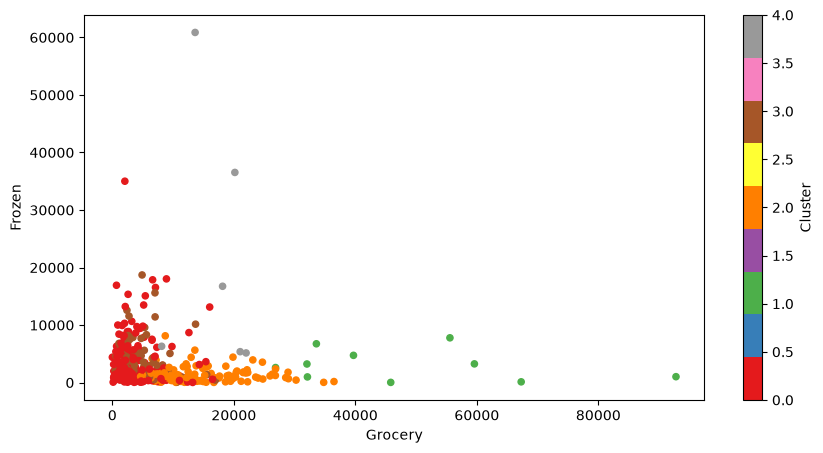

In [86]:
'''
  kind='scatter' : 그래프의 종류. 산점도
  x='Grocery' : x축의 값 
  y='Frozen' : y축의 값
  c='Cluster' : Cluster값을 기준으로 색상을 출력

'''
df.plot(kind='scatter',x='Grocery',y='Frozen',c='Cluster',cmap='Set1',colorbar=True,figsize=(10,5))

In [93]:
#iris데이터를 이용하여 군집 연습하기
from sklearn import datasets
iris = datasets.load_iris()
print(type(iris))

<class 'sklearn.utils._bunch.Bunch'>


In [ ]:
print(iris.target) #그룹화된 값

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


In [ ]:
iris.data

In [96]:
labels = pd.DataFrame(iris.target)
labels.columns = ['labels']
labels.value_counts()

labels
0         50
1         50
2         50
Name: count, dtype: int64

In [ ]:
data = pd.DataFrame(iris.data)
data.columns=["Sepal length","Sepal width","Petal length","Petal width"]
data.info()

In [98]:
#labels, data 2개의 데이터프레임을 df 데이터로 붙여서 저장하기
df = pd.concat([data,labels],axis=1)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Sepal length  150 non-null    float64
 1   Sepal width   150 non-null    float64
 2   Petal length  150 non-null    float64
 3   Petal width   150 non-null    float64
 4   labels        150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [99]:
feature = df[['Sepal length','Sepal width']]
feature.head()

,Sepal length,Sepal width
0,5.1,3.5
1,4.9,3.0
2,4.7,3.2
3,4.6,3.1
4,5.0,3.6


In [100]:
#KMeans 알고리즘으로 군집화하기.
from sklearn import cluster
model = cluster.KMeans(init='k-means++', n_clusters=3)
model.fit(feature)
predict = pd.DataFrame(model.predict(feature))
predict.columns=['predict']

r = pd.concat([feature,predict],axis=1)

In [102]:
r.predict.value_counts()

predict
1    53
0    51
2    46
Name: count, dtype: int64

/Users/apple/Library/Python/3.12/lib/python/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/apple/Library/Python/3.12/lib/python/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


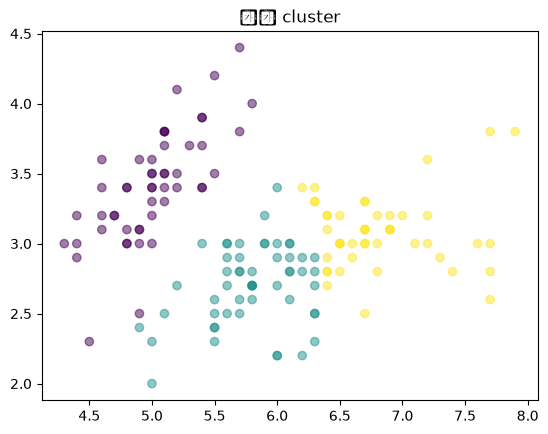

Text(0.5, 1.0, '실제 label')

/Users/apple/Library/Python/3.12/lib/python/site-packages/IPython/core/events.py:101: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/Users/apple/Library/Python/3.12/lib/python/site-packages/IPython/core/events.py:101: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/Users/apple/Library/Python/3.12/lib/python/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/apple/Library/Python/3.12/lib/python/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


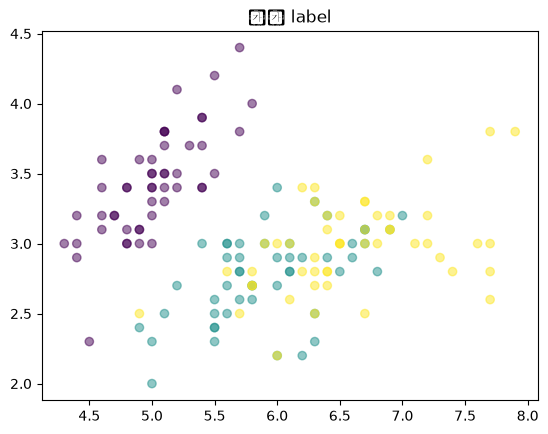

In [ ]:
#예측된 데이터 그래프로 출력하기
fig = plt.figure()
plt.scatter(r['Sepal length'],r['Sepal width'],c=r['predict'],alpha=0.5)
plt.title("predict cluster")
plt.show()
#실제 데이터 그래프로 출력하기
fig = plt.figure()
plt.scatter(df['Sepal length'],df['Sepal width'],c=df['labels'],alpha=0.5)
plt.title("real label")